# ds3

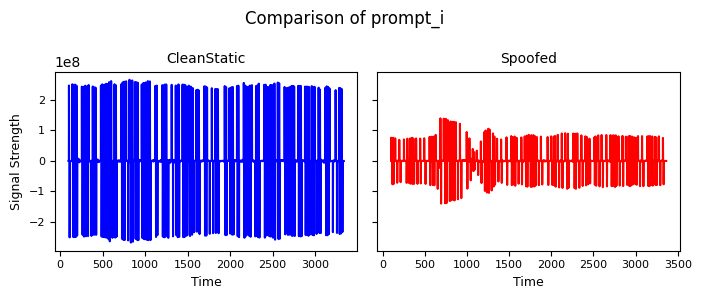

Saved to runtime: /content/output_comparisons/comparison_prompt_i.pdf, /content/output_comparisons/comparison_prompt_i.png


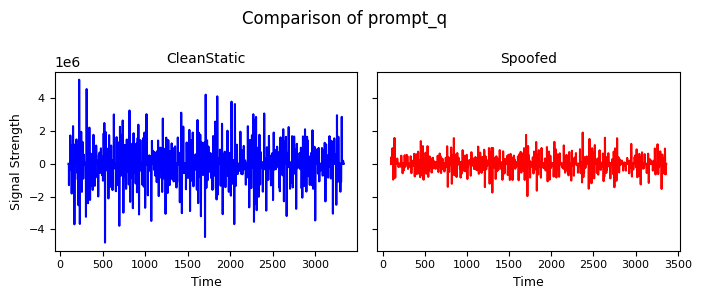

Saved to runtime: /content/output_comparisons/comparison_prompt_q.pdf, /content/output_comparisons/comparison_prompt_q.png


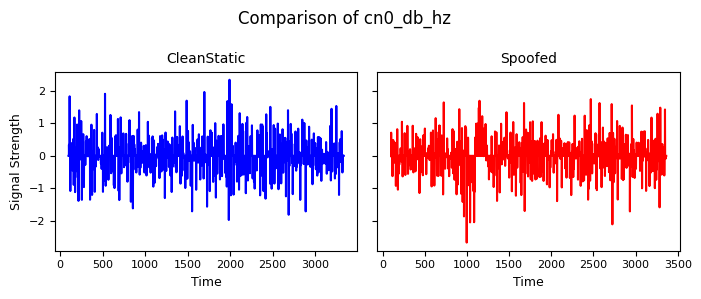

Saved to runtime: /content/output_comparisons/comparison_cn0_db_hz.pdf, /content/output_comparisons/comparison_cn0_db_hz.png


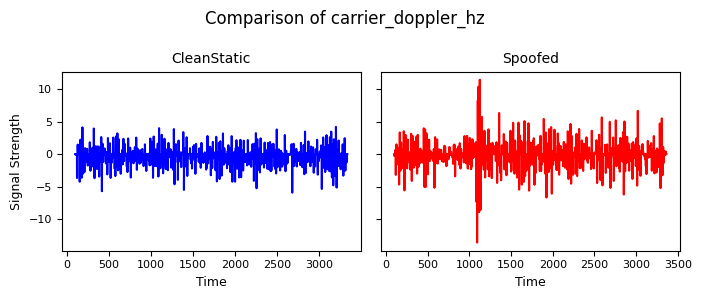

Saved to runtime: /content/output_comparisons/comparison_carrier_doppler_hz.pdf, /content/output_comparisons/comparison_carrier_doppler_hz.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Define base path where GNSS data is stored
base_path = '/content/drive/MyDrive/data/'

# Ensure the runtime output directory exists
runtime_folder = "/content/output_comparisons"
os.makedirs(runtime_folder, exist_ok=True)

# List all dataset paths from base directory
ds_paths = [os.path.join(base_path, ds_path) for ds_path in os.listdir(base_path)]

# Column names for the dataset
columns = ['channel', 'prn', 'acq_doopler_hz', 'acq_doppler_step', 'fs',
           'prompt_i', 'prompt_q', 'cn0_db_hz', 'carrier_doppler_hz',
           'pseudorange_m', 'rx_time']

# Dictionary to store all datasets
dataset_dicts = {}

# Read and process each dataset
for ds_fname in os.listdir(base_path):
    tmp_path = os.path.join(base_path, ds_fname)
    key = ds_fname.split('.')[0]

    # Read CSV file
    tmp_df = pd.read_csv(tmp_path, header=None)

    # Extract PRN values (first 8 available)
    prn_li = [int(tmp_df.iloc[1, 11*i+1]) for i in range(8)]

    # Create a dictionary for the dataset
    dataset_dicts[key] = {
        int(prn_li[0]): tmp_df.iloc[100:, 0:9].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[1]): tmp_df.iloc[100:, 11:20].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[2]): tmp_df.iloc[100:, 22:31].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[3]): tmp_df.iloc[100:, 33:42].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[4]): tmp_df.iloc[100:, 44:53].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[5]): tmp_df.iloc[100:, 55:64].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[6]): tmp_df.iloc[100:, 66:75].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[7]): tmp_df.iloc[100:, 77:86].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        'prn': prn_li
    }

# Assign dataset variables for further use
cs_dict, ds1_dict, ds2_dict, ds3_dict, ds4_dict, ds7_dict, ds8_dict = [dataset_dicts[key] for key in dataset_dicts.keys()]

# Function to compare CleanStatic vs Spoofed GNSS signals and save outputs in runtime
def compare_side_by_side(cs_dict, ds_dict, key, save_name, runtime_dir=runtime_folder):
    """Compare CleanStatic vs Spoofed GNSS signals and save outputs in runtime."""

    # Get first available PRN
    clean_prn = cs_dict['prn'][0]
    spoofed_prn = ds_dict['prn'][0]

    # Extract signal data
    clean_signal = cs_dict[clean_prn][key]
    spoofed_signal = ds_dict[spoofed_prn][key]

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)  # IEEE single-column width
    fig.suptitle(f"Comparison of {key}", fontsize=12)

    # Plot CleanStatic
    axes[0].plot(clean_signal, color='blue')
    axes[0].set_title("CleanStatic", fontsize=10)
    axes[0].set_xlabel("Time", fontsize=9)
    axes[0].set_ylabel("Signal Strength", fontsize=9)
    axes[0].tick_params(axis='both', labelsize=8)

    # Plot Spoofed
    axes[1].plot(spoofed_signal, color='red')
    axes[1].set_title("Spoofed", fontsize=10)
    axes[1].set_xlabel("Time", fontsize=9)
    axes[1].tick_params(axis='both', labelsize=8)

    plt.tight_layout()

    # Define file paths
    pdf_runtime = os.path.join(runtime_dir, f"{save_name}.pdf")
    png_runtime = os.path.join(runtime_dir, f"{save_name}.png")

    # Save images in runtime
    plt.savefig(pdf_runtime, format="pdf", bbox_inches="tight")
    plt.savefig(png_runtime, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to runtime: {pdf_runtime}, {png_runtime}")

# Generate and save separate images for each comparison
compare_side_by_side(cs_dict, ds3_dict, "prompt_i", "comparison_prompt_i")
compare_side_by_side(cs_dict, ds3_dict, "prompt_q", "comparison_prompt_q")
compare_side_by_side(cs_dict, ds3_dict, "cn0_db_hz", "comparison_cn0_db_hz")
compare_side_by_side(cs_dict, ds3_dict, "carrier_doppler_hz", "comparison_carrier_doppler_hz")


# ds4

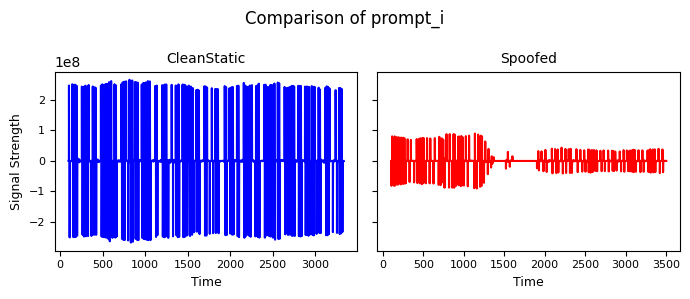

Saved to runtime: /content/output_comparisons/comparison_prompt_i.pdf, /content/output_comparisons/comparison_prompt_i.png


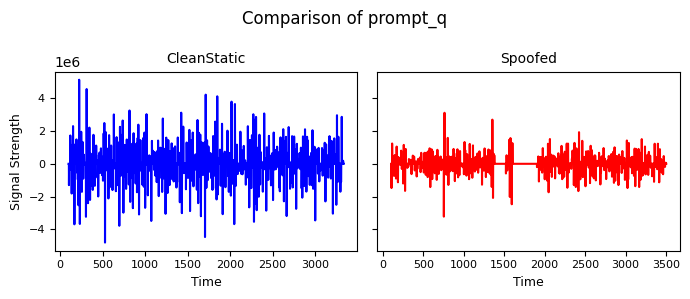

Saved to runtime: /content/output_comparisons/comparison_prompt_q.pdf, /content/output_comparisons/comparison_prompt_q.png


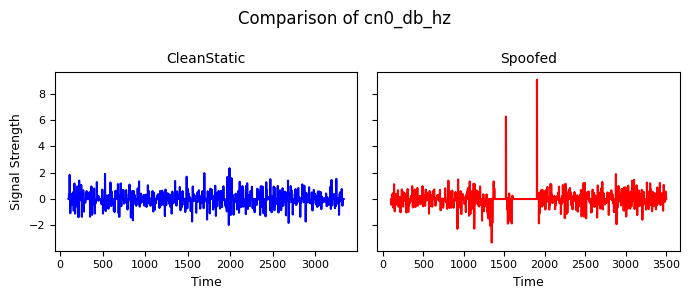

Saved to runtime: /content/output_comparisons/comparison_cn0_db_hz.pdf, /content/output_comparisons/comparison_cn0_db_hz.png


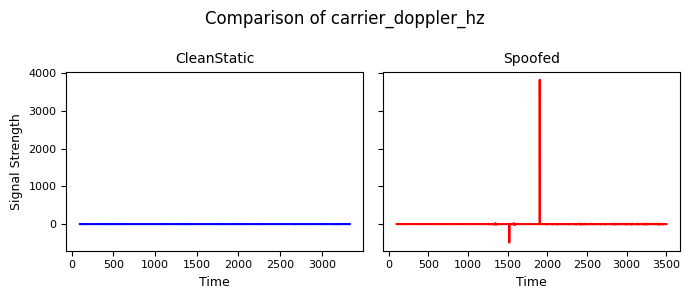

Saved to runtime: /content/output_comparisons/comparison_carrier_doppler_hz.pdf, /content/output_comparisons/comparison_carrier_doppler_hz.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Define base path where GNSS data is stored
base_path = '/content/drive/MyDrive/data/'

# Ensure the runtime output directory exists
runtime_folder = "/content/output_comparisons"
os.makedirs(runtime_folder, exist_ok=True)

# List all dataset paths from base directory
ds_paths = [os.path.join(base_path, ds_path) for ds_path in os.listdir(base_path)]

# Column names for the dataset
columns = ['channel', 'prn', 'acq_doopler_hz', 'acq_doppler_step', 'fs',
           'prompt_i', 'prompt_q', 'cn0_db_hz', 'carrier_doppler_hz',
           'pseudorange_m', 'rx_time']

# Dictionary to store all datasets
dataset_dicts = {}

# Read and process each dataset
for ds_fname in os.listdir(base_path):
    tmp_path = os.path.join(base_path, ds_fname)
    key = ds_fname.split('.')[0]

    # Read CSV file
    tmp_df = pd.read_csv(tmp_path, header=None)

    # Extract PRN values (first 8 available)
    prn_li = [int(tmp_df.iloc[1, 11*i+1]) for i in range(8)]

    # Create a dictionary for the dataset
    dataset_dicts[key] = {
        int(prn_li[0]): tmp_df.iloc[100:, 0:9].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[1]): tmp_df.iloc[100:, 11:20].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[2]): tmp_df.iloc[100:, 22:31].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[3]): tmp_df.iloc[100:, 33:42].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[4]): tmp_df.iloc[100:, 44:53].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[5]): tmp_df.iloc[100:, 55:64].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[6]): tmp_df.iloc[100:, 66:75].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        int(prn_li[7]): tmp_df.iloc[100:, 77:86].rename(columns=lambda x: columns[x % 11]).iloc[:, 5:].diff().fillna(0),
        'prn': prn_li
    }

# Assign dataset variables for further use
cs_dict, ds1_dict, ds2_dict, ds3_dict, ds4_dict, ds7_dict, ds8_dict = [dataset_dicts[key] for key in dataset_dicts.keys()]

# Function to compare CleanStatic vs Spoofed GNSS signals and save outputs in runtime
def compare_side_by_side(cs_dict, ds_dict, key, save_name, runtime_dir=runtime_folder):
    """Compare CleanStatic vs Spoofed GNSS signals and save outputs in runtime."""

    # Get first available PRN
    clean_prn = cs_dict['prn'][0]
    spoofed_prn = ds_dict['prn'][0]

    # Extract signal data
    clean_signal = cs_dict[clean_prn][key]
    spoofed_signal = ds_dict[spoofed_prn][key]

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)  # IEEE single-column width
    fig.suptitle(f"Comparison of {key}", fontsize=12)

    # Plot CleanStatic
    axes[0].plot(clean_signal, color='blue')
    axes[0].set_title("CleanStatic", fontsize=10)
    axes[0].set_xlabel("Time", fontsize=9)
    axes[0].set_ylabel("Signal Strength", fontsize=9)
    axes[0].tick_params(axis='both', labelsize=8)

    # Plot Spoofed
    axes[1].plot(spoofed_signal, color='red')
    axes[1].set_title("Spoofed", fontsize=10)
    axes[1].set_xlabel("Time", fontsize=9)
    axes[1].tick_params(axis='both', labelsize=8)

    plt.tight_layout()

    # Define file paths
    pdf_runtime = os.path.join(runtime_dir, f"{save_name}.pdf")
    png_runtime = os.path.join(runtime_dir, f"{save_name}.png")

    # Save images in runtime
    plt.savefig(pdf_runtime, format="pdf", bbox_inches="tight")
    plt.savefig(png_runtime, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to runtime: {pdf_runtime}, {png_runtime}")

# Generate and save separate images for each comparison
compare_side_by_side(cs_dict, ds4_dict, "prompt_i", "comparison_prompt_i")
compare_side_by_side(cs_dict, ds4_dict, "prompt_q", "comparison_prompt_q")
compare_side_by_side(cs_dict, ds4_dict, "cn0_db_hz", "comparison_cn0_db_hz")
compare_side_by_side(cs_dict, ds4_dict, "carrier_doppler_hz", "comparison_carrier_doppler_hz")
